# Exercise 7.6 — Q2: Go Outdoors or Stay In?

**Lab Book §7.6 Exercise 2 (page 30):**  
> What you do after work in your free time can depend on the weather. If
> it is sunny, you might choose to picnic with a friend, grab a drink with
> a colleague, or run errands. If it is raining, you might stay home and
> watch a movie instead. In this scenario, you have a clear outcome. In
> this case, that is classified as whether to **"go out"** or **"stay in"**.

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** Decision Tree on categorical weather data (classic "play tennis")  
**Dataset:** `datasets/weather_play.csv` — 14 rows × 5 columns:
`outlook`, `temperature`, `humidity`, `wind`, `decision`.

---

## 🎯 Objective

Build a Decision Tree that classifies whether to "Go Out" or "Stay In"
based on the day's weather.

## 📁 Files in this Folder

| File | Description |
|------|-------------|
| `03_Q2_Go_Outdoors.ipynb` | This notebook |
| `datasets/weather_play.csv` | 14-row classic play-tennis dataset |


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '03-Decision-Tree-Classifier'))
    print(f'Running in Google Colab. CWD: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
_PREFIX = 'Q2_Go_Outdoors_'

# Patch plt.show so every figure is also auto-saved as PNG (with prefix to
# avoid collisions between multiple notebooks sharing the same outputs/ dir)
import matplotlib.pyplot as plt
_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'{_PREFIX}figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('Setup complete. Figures will be auto-saved to:', OUTPUT_DIR)


Running locally. CWD: /home/z/my-project/work/build/ML-Lab-Activities/03-Decision-Tree-Classifier


Setup complete. Figures will be auto-saved to: /home/z/my-project/work/build/ML-Lab-Activities/03-Decision-Tree-Classifier/outputs


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Libraries imported.')

Libraries imported.


## 2. Load Dataset

In [3]:
df = pd.read_csv('datasets/weather_play.csv')
print(f"Shape: {df.shape}")
display(df)
print("\nDecision distribution:")
print(df['decision'].value_counts())

Shape: (14, 5)


,outlook,temperature,humidity,wind,decision
0,Sunny,Hot,High,Weak,Go Out
1,Sunny,Hot,High,Strong,Stay In
2,Overcast,Hot,High,Weak,Go Out
3,Rain,Mild,High,Weak,Go Out
4,Rain,Cool,Normal,Weak,Go Out
5,Rain,Cool,Normal,Strong,Stay In
6,Overcast,Cool,Normal,Strong,Go Out
7,Sunny,Mild,High,Weak,Stay In
8,Sunny,Cool,Normal,Weak,Go Out
9,Rain,Mild,Normal,Weak,Go Out



Decision distribution:
decision
Go Out     10
Stay In     4
Name: count, dtype: int64


## 3. Encode Categorical Features

In [4]:
df_enc = df.copy()
encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df[col])
    encoders[col] = le

display(df_enc)
print("Mapping for 'outlook'  :",
      dict(zip(encoders['outlook'].classes_,
               encoders['outlook'].transform(encoders['outlook'].classes_))))
print("Mapping for 'decision':",
      dict(zip(encoders['decision'].classes_,
               encoders['decision'].transform(encoders['decision'].classes_))))

,outlook,temperature,humidity,wind,decision
0,2,1,0,1,0
1,2,1,0,0,1
2,0,1,0,1,0
3,1,2,0,1,0
4,1,0,1,1,0
5,1,0,1,0,1
6,0,0,1,0,0
7,2,2,0,1,1
8,2,0,1,1,0
9,1,2,1,1,0


Mapping for 'outlook'  : {'Overcast': np.int64(0), 'Rain': np.int64(1), 'Sunny': np.int64(2)}
Mapping for 'decision': {'Go Out': np.int64(0), 'Stay In': np.int64(1)}


## 4. Define Features & Target

In [5]:
X = df_enc[['outlook', 'temperature', 'humidity', 'wind']]
y = df_enc['decision']
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (14, 4), y shape: (14,)


## 5. Train Decision Tree (entropy)

In [6]:
model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy on full data: {accuracy_score(y, y_pred):.4f}")
print(classification_report(y, y_pred,
      target_names=encoders['decision'].classes_))

Accuracy on full data: 1.0000
              precision    recall  f1-score   support

      Go Out       1.00      1.00      1.00        10
     Stay In       1.00      1.00      1.00         4

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



## 6. Visualise the Tree

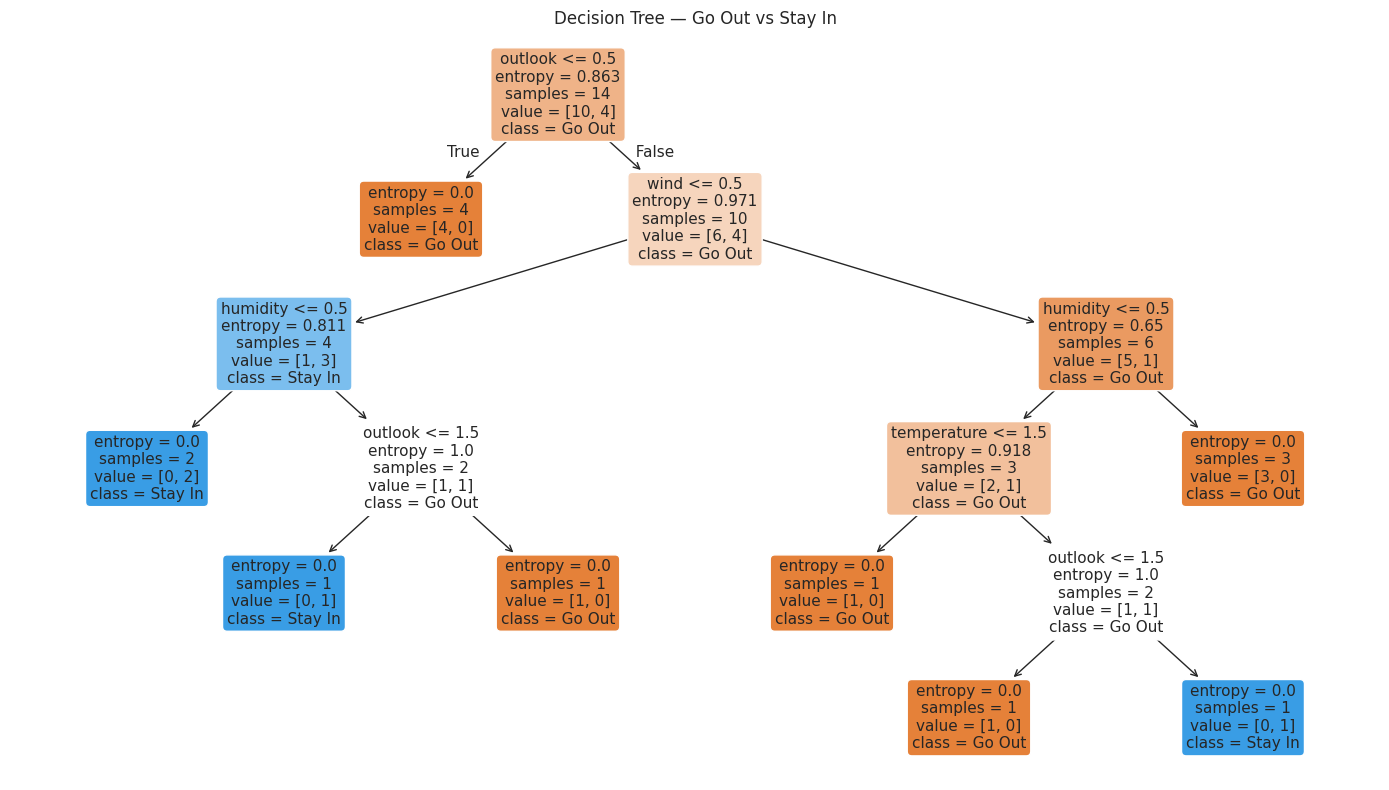

In [7]:
plt.figure(figsize=(14, 8))
plot_tree(model,
          feature_names=['outlook', 'temperature', 'humidity', 'wind'],
          class_names=list(encoders['decision'].classes_),
          filled=True, rounded=True, fontsize=11)
plt.title('Decision Tree — Go Out vs Stay In')
plt.tight_layout()
plt.show()

## 7. Predict for a New Day

In [8]:
# Predict for a sunny, mild, normal-humidity, weak-wind day
new_day = pd.DataFrame({
    'outlook':    ['Sunny'],
    'temperature':['Mild'],
    'humidity':   ['Normal'],
    'wind':       ['Weak'],
})
new_enc = pd.DataFrame({
    'outlook':    [encoders['outlook'].transform(['Sunny'])[0]],
    'temperature':[encoders['temperature'].transform(['Mild'])[0]],
    'humidity':   [encoders['humidity'].transform(['Normal'])[0]],
    'wind':       [encoders['wind'].transform(['Weak'])[0]],
})
pred = model.predict(new_enc)[0]
print(f"Sunny / Mild / Normal humidity / Weak wind → {encoders['decision'].classes_[pred]}")

Sunny / Mild / Normal humidity / Weak wind → Go Out


## 📚 Key Takeaways
- Decision Trees handle **categorical** features after Label Encoding (or
  one-hot).
- The classic "play tennis" dataset is small (14 rows) — the tree memorises
  it (training accuracy = 100%).
- `outlook` is typically the most important feature (highest information
  gain).
